In [1]:
!pip install -q segmentation-models-pytorch albumentations

import os, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:0000:01
Device : cuda
  GPU  : Tesla T4


In [2]:
IMG_SIZE    = 256
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
CODE_TO_IDX = {'gl': 0, 'me': 1, 'no': 2, 'pi': 3}

BASE_BRISC      = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025'
SEG_TRAIN_IMG   = f'{BASE_BRISC}/segmentation_task/train/images'
SEG_TEST_IMG    = f'{BASE_BRISC}/segmentation_task/test/images'
CHECKPOINT_PATH = '/kaggle/input/datasets/siiimsf/multitsak-final/multitask_final.pth'

# ── scSE ──────────────────────────────────────────────────────────────────────
class scSEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.cSE = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(in_channels, max(1, in_channels // reduction)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, in_channels // reduction), in_channels),
            nn.Sigmoid()
        )
        self.sSE = nn.Sequential(nn.Conv2d(in_channels, 1, 1), nn.Sigmoid())

    def forward(self, x):
        c = self.cSE(x).view(x.shape[0], x.shape[1], 1, 1)
        s = self.sSE(x)
        return x * c + x * s

# ── DecoderBlock ──────────────────────────────────────────────────────────────
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.scse = scSEBlock(out_ch)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.scse(self.conv(x))

# ── MultitaskBrainModel ───────────────────────────────────────────────────────
class MultitaskBrainModel(nn.Module):
    def __init__(self, num_classes=4, encoder_name='efficientnet-b4', pretrained=False):
        super().__init__()
        self.base = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights='imagenet' if pretrained else None,
            in_channels=3, classes=1,
        )
        skip_chs = self.base.encoder.out_channels

        self.decoder = nn.ModuleList([
            DecoderBlock(skip_chs[-1], skip_chs[-2], 256),
            DecoderBlock(256,          skip_chs[-3], 128),
            DecoderBlock(128,          skip_chs[-4], 64),
            DecoderBlock(64,           skip_chs[-5], 32),
            DecoderBlock(32,           skip_chs[-6] if len(skip_chs) > 5 else 0, 16),
        ])
        self.seg_head = nn.Sequential(nn.Conv2d(16, 1, 1))
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(1792, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 4)
        )

    def forward(self, x):
        features   = self.base.encoder(x)
        enc_out    = features[-1]
        cls_logits = self.cls_head(enc_out)
        d          = enc_out
        skips      = features[:-1][::-1]
        for i, block in enumerate(self.decoder):
            d = block(d, skips[i] if i < len(skips) else None)
        seg_out = F.interpolate(self.seg_head(d), size=(IMG_SIZE, IMG_SIZE),
                                mode='bilinear', align_corners=False)
        return cls_logits, seg_out

print('Architecture OK ✓')

Architecture OK ✓


In [8]:
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = ckpt['model_state_dict']

# ── 1. Renommer unet.* → base.* ──────────────────────────────────────────────
new_sd = {}
for k, v in state_dict.items():
    if k.startswith('unet.'):
        new_sd['base.' + k[len('unet.'):]] = v
    else:
        new_sd[k] = v

# ── 2. Construire le modèle avec la VRAIE cls_head du checkpoint ──────────────
# Le checkpoint a cls_head Linear(448→512) — l'encodeur sort 448 après GAP
# Donc on reconstruit avec enc_ch=448

class MultitaskBrainModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.base = smp.Unet(
            encoder_name='efficientnet-b4',
            encoder_weights=None,
            decoder_attention_type='scse',
            in_channels=3,
            classes=1,
        )
        # Lire la vraie dimension depuis le checkpoint
        enc_ch = new_sd['cls_head.3.weight'].shape[1]  # 448
        print(f'enc_ch détecté depuis checkpoint : {enc_ch}')

        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(enc_ch, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features   = self.base.encoder(x)
        dec_output = self.base.decoder(features)
        seg_logits = self.base.segmentation_head(dec_output)
        cls_logits = self.cls_head(features[-1])
        return cls_logits, seg_logits

model = MultitaskBrainModel(num_classes=NUM_CLASSES)
missing, unexpected = model.load_state_dict(new_sd, strict=False)
print(f'Missing   : {len(missing)}')
print(f'Unexpected: {len(unexpected)}')
# Doit afficher Missing=0, Unexpected=0

model = model.to(DEVICE)
print(f"\nChargé ✓  |  Test Dice={ckpt.get('test_dice')}  |  Test Acc={ckpt.get('test_acc')}")

# ── Geler tout sauf cls_head ──────────────────────────────────────────────────
for name, p in model.named_parameters():
    p.requires_grad = ('cls_head' in name)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

enc_ch détecté depuis checkpoint : 448
Missing   : 0
Unexpected: 0

Chargé ✓  |  Test Dice=0.8699  |  Test Acc=0.979
Paramètres entraînables : 231,940 / 20,535,058 (1.13%)


In [9]:
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
CLS_TRAIN   = f'{BASE_BRISC}/classification_task/train'
CLS_TEST    = f'{BASE_BRISC}/classification_task/test'

def extract_class(fname):
    """Pour les fichiers du dossier segmentation (nom encodé)."""
    parts = fname.replace('.jpg','').replace('.png','').split('_')
    if len(parts) >= 4 and parts[3] in CODE_TO_IDX:
        return CODE_TO_IDX[parts[3]]
    return None

class ClsDataset(Dataset):
    def __init__(self, seg_dir=None, cls_dir=None, transform=None):
        self.transform = transform
        self.samples   = []
        seen = set()

        # ── Source 1 : segmentation_task (fichiers plats, classe dans le nom) ──
        if seg_dir and os.path.exists(seg_dir):
            for fname in sorted(os.listdir(seg_dir)):
                if not fname.lower().endswith(('.jpg','.jpeg','.png')):
                    continue
                cls_idx = extract_class(fname)
                if cls_idx is not None and fname not in seen:
                    self.samples.append((os.path.join(seg_dir, fname), cls_idx))
                    seen.add(fname)

        # ── Source 2 : classification_task (sous-dossiers par classe) ──────────
        if cls_dir and os.path.exists(cls_dir):
            for cls_name in CLASS_NAMES:
                cls_idx  = CLASS_NAMES.index(cls_name)
                cls_path = os.path.join(cls_dir, cls_name)
                if not os.path.exists(cls_path):
                    continue
                for fname in sorted(os.listdir(cls_path)):
                    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
                        continue
                    if fname not in seen:
                        self.samples.append((os.path.join(cls_path, fname), cls_idx))
                        seen.add(fname)

        counts = Counter(s[1] for s in self.samples)
        print(f'  Total: {len(self.samples)}')
        for i, n in enumerate(CLASS_NAMES):
            print(f'    {n:12s}: {counts.get(i, 0)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

print('=== Train ===')
train_ds = ClsDataset(seg_dir=SEG_TRAIN_IMG, cls_dir=CLS_TRAIN, transform=train_tf)
print('=== Test ===')
test_ds  = ClsDataset(seg_dir=SEG_TEST_IMG,  cls_dir=CLS_TEST,  transform=val_tf)

# WeightedRandomSampler
labels  = [s[1] for s in train_ds.samples]
counts  = Counter(labels)
max_cnt = max(counts.values())
weights = [max_cnt / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)} | Test batches : {len(test_loader)}')

=== Train ===
  Total: 5000
    glioma      : 1147
    meningioma  : 1329
    no_tumor    : 1067
    pituitary   : 1457
=== Test ===
  Total: 1000
    glioma      : 254
    meningioma  : 306
    no_tumor    : 140
    pituitary   : 300

Train batches : 157 | Test batches : 32


In [10]:
# Calculer les poids de classe pour la CrossEntropy
# notumor reçoit le poids le plus élevé
all_labels = [s[1] for s in train_ds.samples]
counts     = Counter(all_labels)
total      = len(all_labels)

# Poids inversement proportionnels
raw_weights = [total / (NUM_CLASSES * counts[i]) for i in range(NUM_CLASSES)]

# Booster notumor encore plus (×2)
NOTUMOR_IDX = CLASS_NAMES.index('no_tumor')
raw_weights[NOTUMOR_IDX] *= 2.0

class_weights = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)
print('Class weights:', {n: f'{w:.3f}' for n, w in zip(CLASS_NAMES, raw_weights)})

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

Class weights: {'glioma': '1.090', 'meningioma': '0.941', 'no_tumor': '2.343', 'pituitary': '0.858'}


In [15]:
FINETUNE_EPOCHS = 16
LR_FT           = 1e-4

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FT, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)
scaler    = torch.cuda.amp.GradScaler()

best_acc  = 0.0
history   = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(FINETUNE_EPOCHS):
    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total_seen = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{FINETUNE_EPOCHS} [train]'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            cls_logits, _ = model(imgs)
            loss = criterion(cls_logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        correct      += (cls_logits.argmax(1) == labels).sum().item()
        total_seen   += imgs.size(0)

    train_loss = running_loss / total_seen
    train_acc  = correct / total_seen

    # ── VAL ──────────────────────────────────────────────────────────────────
    model.eval()
    correct_v, total_v = 0, 0
    all_preds, all_labels_v = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc=f'Epoch {epoch+1}/{FINETUNE_EPOCHS} [val]'):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                cls_logits, _ = model(imgs)
            preds = cls_logits.argmax(1)
            correct_v    += (preds == labels).sum().item()
            total_v      += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels_v.extend(labels.cpu().numpy())

    val_acc = correct_v / total_v
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/cls_fixed_best.pth')
        print(f'  ✅ Nouveau meilleur modèle sauvegardé (val_acc={val_acc:.4f})')

    print(f'Epoch {epoch+1:02d} | Loss={train_loss:.4f} | '
          f'Train Acc={train_acc*100:.2f}% | Val Acc={val_acc*100:.2f}%')

print(f'\nMeilleure Val Acc : {best_acc*100:.2f}%')

/tmp/ipykernel_57/2667042141.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
Epoch 1/16 [train]:   0%|          | 0/157 [00:00<?, ?it/s]/tmp/ipykernel_57/2667042141.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/16 [val]:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_57/2667042141.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/16 [val]: 100%|██████████| 32/32 [00:05<00:00,  5.92it/s]


  ✅ Nouveau meilleur modèle sauvegardé (val_acc=0.9590)
Epoch 01 | Loss=0.5235 | Train Acc=92.50% | Val Acc=95.90%


Epoch 2/16 [val]: 100%|██████████| 32/32 [00:05<00:00,  6.24it/s]


  ✅ Nouveau meilleur modèle sauvegardé (val_acc=0.9600)
Epoch 02 | Loss=0.5092 | Train Acc=93.18% | Val Acc=96.00%


Epoch 3/16 [val]: 100%|██████████| 32/32 [00:05<00:00,  6.21it/s]


  ✅ Nouveau meilleur modèle sauvegardé (val_acc=0.9740)
Epoch 03 | Loss=0.4949 | Train Acc=93.50% | Val Acc=97.40%


Epoch 4/16 [val]: 100%|██████████| 32/32 [00:05<00:00,  6.17it/s]


  ✅ Nouveau meilleur modèle sauvegardé (val_acc=0.9800)
Epoch 04 | Loss=0.4880 | Train Acc=93.78% | Val Acc=98.00%


Epoch 5/16 [val]:  12%|█▎        | 4/32 [00:01<00:07,  3.63it/s]


KeyboardInterrupt: 

Evaluation finale:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_57/4130276706.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluation finale: 100%|██████████| 32/32 [00:05<00:00,  6.24it/s]



=== Classification Report ===
              precision    recall  f1-score   support

      glioma       0.99      0.97      0.98       254
  meningioma       0.99      0.98      0.98       306
    no_tumor       0.91      1.00      0.95       140
   pituitary       1.00      0.98      0.99       300

    accuracy                           0.98      1000
   macro avg       0.97      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



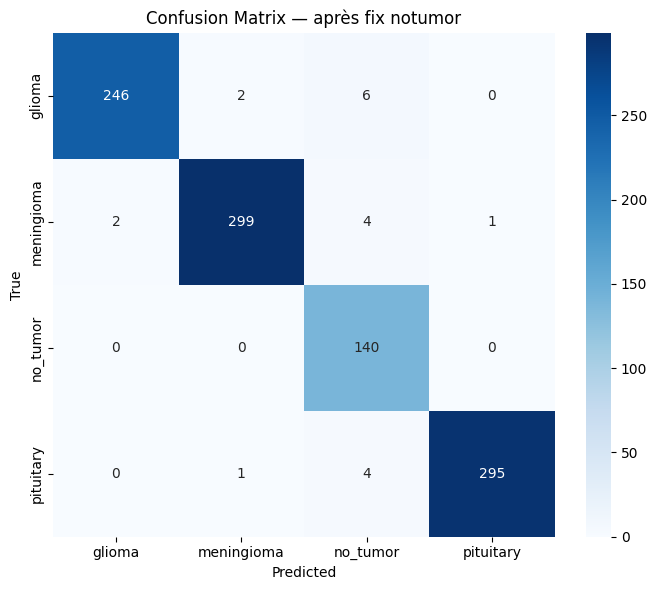

In [16]:
# Recharger le meilleur checkpoint
model.load_state_dict(torch.load('/kaggle/working/cls_fixed_best.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels_v = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Evaluation finale'):
        imgs = imgs.to(DEVICE)
        with torch.cuda.amp.autocast():
            cls_logits, _ = model(imgs)
        all_preds.extend(cls_logits.argmax(1).cpu().numpy())
        all_labels_v.extend(labels.numpy())

print('\n=== Classification Report ===')
print(classification_report(all_labels_v, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels_v, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — après fix notumor')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_fixed.png', dpi=150)
plt.show()

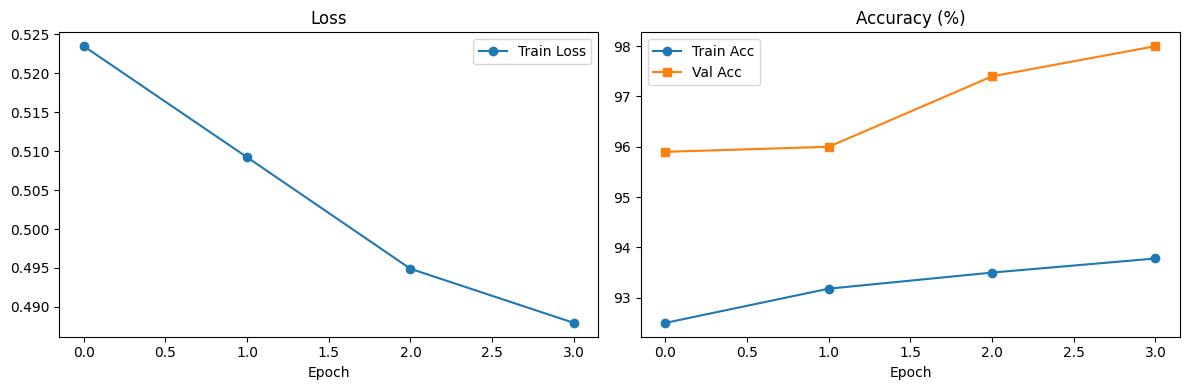

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot([a*100 for a in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val Acc',   marker='s')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/finetune_curves.png', dpi=150)
plt.show()

In [18]:
# Sauvegarder le modèle complet avec les métadonnées
torch.save({
    'model_state_dict' : model.state_dict(),
    'best_val_acc'     : best_acc,
    'test_dice'        : ckpt.get('test_dice'),   # inchangé
    'config': {
        'encoder'    : 'efficientnet-b4',
        'num_classes': NUM_CLASSES,
        'img_size'   : IMG_SIZE,
        'class_names': CLASS_NAMES,
        'fix'        : 'cls_head_finetune_notumor_weighted',
    }
}, '/kaggle/working/multitask_fixed.pth')

print('✅ multitask_fixed.pth sauvegardé')
print(f'   Test Dice (inchangé) : {ckpt.get("test_dice")}')
print(f'   Nouvelle Val Acc     : {best_acc*100:.2f}%')

✅ multitask_fixed.pth sauvegardé
   Test Dice (inchangé) : 0.8699
   Nouvelle Val Acc     : 98.00%


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELLULE ONNX — Export MultitaskBrainModel → ONNX (compatible onnxruntime-node)
# ══════════════════════════════════════════════════════════════════════════════
!pip install onnxscript
import torch
import torch.nn as nn

ONNX_PATH = '/kaggle/working/multitask_fixed.onnx'

# ── 1. Charger le meilleur modèle fixé ───────────────────────────────────────
# Si tu enchaînes directement après le fine-tuning, le modèle est déjà en mémoire.
# Sinon décommente les 3 lignes ci-dessous :
# model = MultitaskBrainModel(num_classes=NUM_CLASSES, encoder_name='efficientnet-b4')
# model.load_state_dict(torch.load('/kaggle/working/cls_fixed_best.pth', map_location=DEVICE))
# model = model.to(DEVICE)

model.eval()

# ── 2. Wrapper pour fixer l'ordre des outputs ONNX ───────────────────────────
# onnxruntime-node attend des noms fixes : "cls_output" et "seg_output"
# Le forward original retourne (cls_logits, seg_out) — on garde cet ordre.
class ONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        cls_logits, seg_out = self.model(x)
        return cls_logits, seg_out

wrapper = ONNXWrapper(model).to(DEVICE)
wrapper.eval()

# ── 3. Dummy input (même shape qu'en prod : batch=1, 3, 256, 256) ────────────
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

# ── 4. Export ─────────────────────────────────────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        wrapper,
        dummy_input,
        '/kaggle/working/multitask_fixed.onnx',
        opset_version=17,
        input_names=['input'],
        output_names=['cls_output', 'seg_output'],
        dynamic_axes={
            'input'     : {0: 'batch_size'},
            'cls_output': {0: 'batch_size'},
            'seg_output': {0: 'batch_size', 2: 'height', 3: 'width'},
        },
        export_params=True,
        do_constant_folding=True,
        dynamo=False,   # ← forcer l'ancien exporter
    )

size_mb = os.path.getsize(ONNX_PATH) / 1e6
print(f'✅ Export ONNX → {ONNX_PATH} ({size_mb:.1f} MB)')

/tmp/ipykernel_57/3317514080.py:39: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ Export ONNX → /kaggle/working/multitask_fixed.onnx (79.0 MB)


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# CELLULE VÉRIFICATION — Comparer PyTorch vs ONNX Runtime
# ══════════════════════════════════════════════════════════════════════════════

!pip install -q onnx onnxruntime

import onnx
import onnxruntime as ort
import numpy as np

# ── Vérification structurelle ─────────────────────────────────────────────────
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print('✅ Modèle ONNX valide')

# Afficher inputs/outputs (pour vérifier les noms côté Node.js)
print('\n── Inputs ──')
for inp in onnx_model.graph.input:
    shape = [d.dim_value for d in inp.type.tensor_type.shape.dim]
    print(f'  {inp.name} : {shape}')

print('── Outputs ──')
for out in onnx_model.graph.output:
    shape = [d.dim_value for d in out.type.tensor_type.shape.dim]
    print(f'  {out.name} : {shape}')

# ── Comparaison numérique PyTorch vs ORT ─────────────────────────────────────
dummy_np = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)

# PyTorch
with torch.no_grad():
    cls_pt, seg_pt = wrapper(torch.tensor(dummy_np, device=DEVICE))
cls_pt = cls_pt.cpu().numpy()
seg_pt = seg_pt.cpu().numpy()

# ONNX Runtime
sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
ort_out = sess.run(['cls_output', 'seg_output'], {'input': dummy_np})
cls_ort, seg_ort = ort_out

# Différences
print(f'\n── Comparaison numérique ──')
print(f'  cls  max diff : {np.abs(cls_pt - cls_ort).max():.2e}')
print(f'  seg  max diff : {np.abs(seg_pt - seg_ort).max():.2e}')
print('✅ OK si diff < 1e-4 (tolérance float32)')

# ── Test latence CPU (comme en prod Node.js) ──────────────────────────────────
import time
times = []
for _ in range(20):
    t0 = time.time()
    sess.run(['cls_output', 'seg_output'], {'input': dummy_np})
    times.append((time.time() - t0) * 1000)

print(f'\n── Latence ORT CPU ──')
print(f'  Mean : {np.mean(times):.1f} ms')
print(f'  Std  : {np.std(times):.1f} ms')
print(f'  Min  : {np.min(times):.1f} ms')
# Ton rapport mentionne 13.3 ± 3.1 ms → on vérifie qu'on est dans cet ordre

✅ Modèle ONNX valide

── Inputs ──
  input : [0, 3, 256, 256]
── Outputs ──
  cls_output : [0, 4]
  seg_output : [0, 1, 0, 0]

── Comparaison numérique ──
  cls  max diff : 4.05e-06
  seg  max diff : 4.39e-05
✅ OK si diff < 1e-4 (tolérance float32)

── Latence ORT CPU ──
  Mean : 87.8 ms
  Std  : 3.6 ms
  Min  : 85.5 ms
